In [1]:
!pip install kagglehub

In [2]:
import pandas as pd
import kagglehub

# download dataset
path = kagglehub.dataset_download("altruistdelhite04/loan-prediction-problem-dataset")

print("Path:", path)



Path: /Users/omarawilhassan/.cache/kagglehub/datasets/altruistdelhite04/loan-prediction-problem-dataset/versions/1


In [3]:
import pandas as pd

file_path = path + "/train_u6lujuX_CVtuZ9i.csv"

df = pd.read_csv(file_path)

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [5]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [7]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

## DATA CLEANING

In [8]:
# Check overlap of missing values
missing_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'LoanAmount', 'Loan_Amount_Term','Credit_History']
rows_with_any_missing = df[missing_cols].isna().any(axis=1).sum()

print(f"Rows with at least one missing: {rows_with_any_missing}")

Rows with at least one missing: 134


In [9]:
# Start fresh with original dataframe
df_clean = df.copy()

# Now check columns (this will work)
print(df_clean.columns.tolist())

['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


In [10]:
# Step 1: Drop rows from columns with VERY FEW missing (≤ 15 missing)
df_clean = df.dropna(subset=['Gender', 'Married', 'Dependents', 'Loan_Amount_Term'])

In [11]:
df_clean.isna().sum()

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed        31
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           20
Loan_Amount_Term      0
Credit_History       49
Property_Area         0
Loan_Status           0
dtype: int64

In [12]:
# Step 2: Fill missing values (impute)
df_clean['Self_Employed'] = df_clean['Self_Employed'].fillna(df_clean['Self_Employed'].mode()[0])
df_clean['Credit_History'] = df_clean['Credit_History'].fillna(df_clean['Credit_History'].mode()[0])
df_clean['LoanAmount'] = df_clean['LoanAmount'].fillna(df_clean['LoanAmount'].median())
df_clean['Loan_Amount_Term'] = df_clean['Loan_Amount_Term'].fillna(df_clean['Loan_Amount_Term'].median())

# Step 3: Drop rows from columns with very few missing values
df_clean = df_clean.dropna(subset=['Gender', 'Married', 'Dependents'])

# Step 4: Verify result
print(f"Original rows: {len(df)}")
print(f"Clean rows: {len(df_clean)}")
print(f"Missing values left: {df_clean.isna().sum().sum()}")

Original rows: 614
Clean rows: 573
Missing values left: 0


/var/folders/pm/q4yvkd714csgg8r51zylyjy00000gp/T/ipykernel_14372/25664286.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Self_Employed'] = df_clean['Self_Employed'].fillna(df_clean['Self_Employed'].mode()[0])
/var/folders/pm/q4yvkd714csgg8r51zylyjy00000gp/T/ipykernel_14372/25664286.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Credit_History'] = df_clean['Credit_History'].fillna(df_clean['Credit_History'].mode()[0])
/var/folders/pm/q4yvkd714csgg8r51zylyjy00000gp/T/ipykernel_14

In [13]:
df_clean.isna().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [14]:
df_clean.to_csv("loan_clean_notIncoded.csv", index=False)

## EDA (BANK ANALYST MODE)

### 1. Do people with Credit_History = 1 get approved more?

In [14]:
df.groupby("Credit_History")["Loan_Status"].value_counts(normalize=True)

Credit_History  Loan_Status
0.0             N              0.921348
                Y              0.078652
1.0             Y              0.795789
                N              0.204211
Name: proportion, dtype: float64

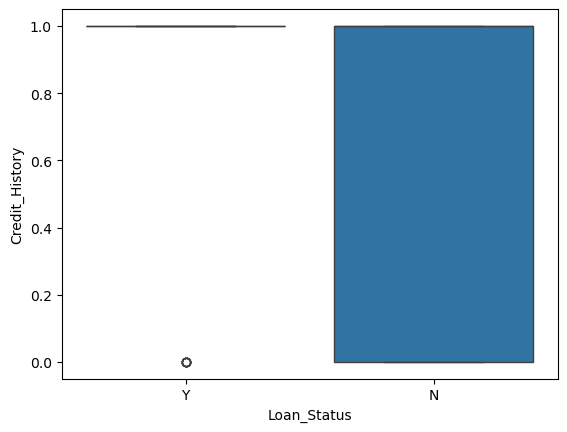

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['Loan_Status'], y=df['Credit_History'])
plt.show()

##### Insight: Customers with Credit_History = 1 have higher loan approval rates.
##### Evidence: Higher proportion of “Y” (approved loans) in Credit_History = 1 group.
##### conclusion: Credit history is a strong predictor of loan approval.

### 2. Does income affect Loan_Status?

In [16]:
df_clean.groupby("ApplicantIncome") ["Loan_Status"].value_counts(normalize = True)

ApplicantIncome  Loan_Status
150              N              1.0
210              Y              1.0
416              N              1.0
645              Y              1.0
1000             N              1.0
                               ... 
37719            Y              1.0
39147            Y              1.0
39999            Y              1.0
63337            Y              1.0
81000            N              1.0
Name: proportion, Length: 499, dtype: float64

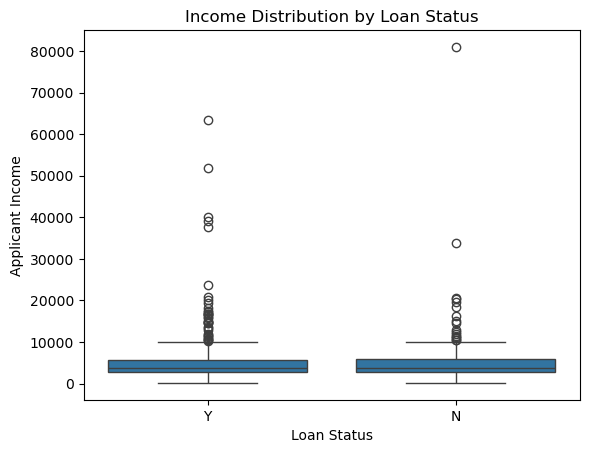

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['Loan_Status'], y=df['ApplicantIncome'])
plt.xlabel('Loan Status')
plt.ylabel('Applicant Income')
plt.title('Income Distribution by Loan Status')
plt.show()

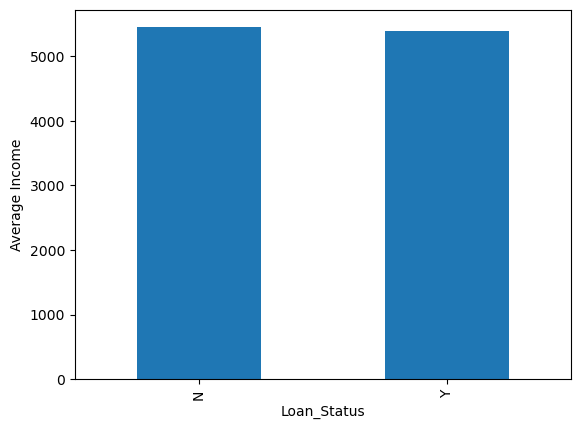

             count         mean          std    min     25%     50%      75%  \
Loan_Status                                                                    
N            192.0  5446.078125  6819.558528  150.0  2885.0  3833.5  5861.25   
Y            422.0  5384.068720  5765.441615  210.0  2877.5  3812.5  5771.50   

                 max  
Loan_Status           
N            81000.0  
Y            63337.0  


In [18]:
# Grouped bar chart (mean income by loan status)
df.groupby('Loan_Status')['ApplicantIncome'].mean().plot(kind='bar')
plt.ylabel('Average Income')
plt.show()

# Print actual numbers
print(df.groupby('Loan_Status')['ApplicantIncome'].describe())

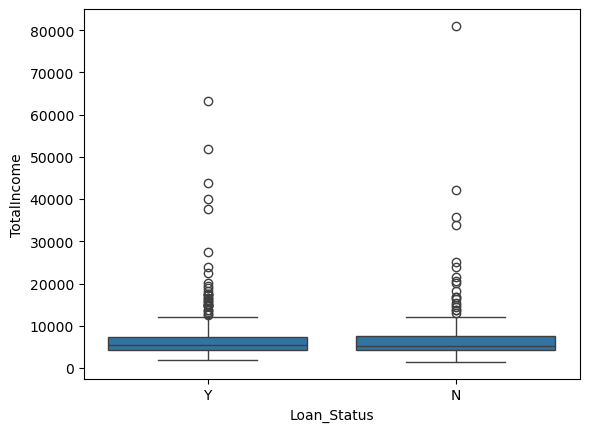

In [19]:
# Total household income
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']

sns.boxplot(x=df['Loan_Status'], y=df['TotalIncome'])
plt.show()

##### Insight:Applicant income shows weak separation between approved and rejected loans.
##### Evidence: Boxplots for both Loan_Status classes overlap significantly.
##### conclusion: Income alone is not a strong predictor of loan approval, but may still contribute when combined with other features.

### 3. Does education level affect approval rate?

In [20]:
df_clean.groupby("Education") ["Loan_Status"].value_counts(normalize = True)

Education     Loan_Status
Graduate      Y              0.711111
              N              0.288889
Not Graduate  Y              0.634146
              N              0.365854
Name: proportion, dtype: float64

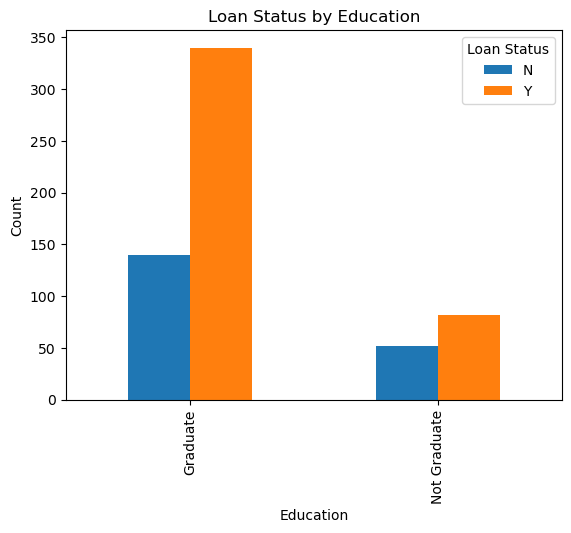

In [21]:
pd.crosstab(df['Education'], df['Loan_Status']).plot(kind='bar', stacked=False)
plt.xlabel('Education')
plt.ylabel('Count')
plt.title('Loan Status by Education')
plt.legend(title='Loan Status')
plt.show()

#### Graduates have a slightly higher loan approval rate than non-graduates.

#### Evidence: 71.1% of graduates are approved compared to 63.4% of non-graduates.

#### conclusion: Education has a moderate influence on loan approval, but it is not a strong standalone predictor.

### 4. Does Property_Area matter?

In [22]:
df_clean.groupby("Property_Area") ["Loan_Status"].value_counts(normalize = True)

Property_Area  Loan_Status
Rural          Y              0.621302
               N              0.378698
Semiurban      Y              0.776256
               N              0.223744
Urban          Y              0.664865
               N              0.335135
Name: proportion, dtype: float64

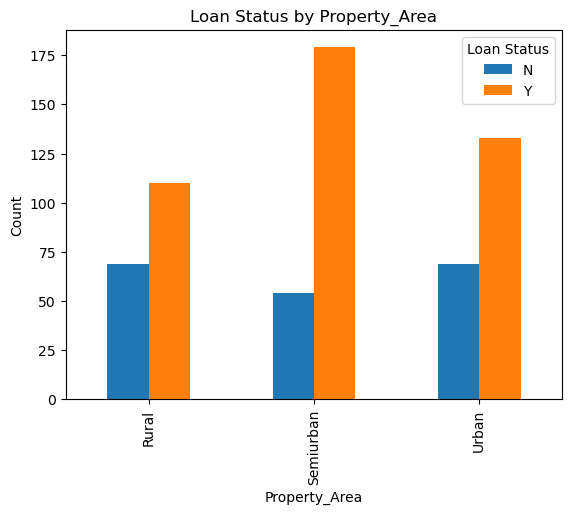

In [23]:
pd.crosstab(df['Property_Area'], df['Loan_Status']).plot(kind='bar', stacked=False)
plt.xlabel('Property_Area')
plt.ylabel('Count')
plt.title('Loan Status by Property_Area')
plt.legend(title='Loan Status')
plt.show()

#### insight: Customers from semiurban areas have the highest loan approval rates compared to urban and rural areas.

#### Evidence: 77.6% of semiurban applicants are approved, compared to 66.5% (urban) and 62.1% (rural).

#### conclusion: Property area has a moderate influence on loan approval, with semiurban customers being more likely to #### receive loans.
#### Reaaon: his may be because semiurban customers represent a balance between financial stability (like urban areas) and  lower risk or competition (compared to rural areas), making them more attractive to lenders.

## EATURE ENGINEERING

In [24]:
# 1. Total Income (essential)
df_clean['TotalIncome'] = df_clean['ApplicantIncome'] + df_clean['CoapplicantIncome']

# 2. Loan to Income ratio (most powerful predictor)
df_clean['LoanToIncome'] = df_clean['LoanAmount'] / (df_clean['TotalIncome']+ 1)

# 3. EMI to Income ratio (affordability)
df_clean['EMI'] = df_clean['LoanAmount'] / df_clean['Loan_Amount_Term']
df_clean['EMItoIncome'] = df_clean['EMI'] / (df_clean['TotalIncome']+1)

df_clean['Has_Coapplicant'] = (df_clean['CoapplicantIncome'] > 0).astype(int)


In [25]:
df_clean.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,LoanToIncome,EMI,EMItoIncome,Has_Coapplicant
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y,5849.0,0.021880,0.355556,0.000061,0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0,0.021011,0.355556,0.000058,1
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0,0.021993,0.183333,0.000061,0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0,0.024282,0.333333,0.000067,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0,0.023496,0.391667,0.000065,0


## MODEL BUILDING

#### Encoding categorical variables before model building 

In [26]:
# Binary columns (Label Encoding)
df_clean['Gender'] = df_clean['Gender'].map({'Male': 1, 'Female': 0})
df_clean['Married'] = df_clean['Married'].map({'Yes': 1, 'No': 0})
df_clean['Education'] = df_clean['Education'].map({'Graduate': 1, 'Not Graduate': 0})
df_clean['Self_Employed'] = df_clean['Self_Employed'].map({'Yes': 1, 'No': 0})
df_clean['Loan_Status'] = df_clean['Loan_Status'].map({'Y': 1, 'N': 0})

# Multi-category columns (One-Hot Encoding)
df_clean = pd.get_dummies(df_clean, columns=['Property_Area'], drop_first=True)
df_clean = pd.get_dummies(df_clean, columns=['Dependents'], drop_first=True)

In [27]:
print(df_clean.dtypes)
print(df_clean.head())

Loan_ID                     object
Gender                       int64
Married                      int64
Education                    int64
Self_Employed                int64
ApplicantIncome              int64
CoapplicantIncome          float64
LoanAmount                 float64
Loan_Amount_Term           float64
Credit_History             float64
Loan_Status                  int64
TotalIncome                float64
LoanToIncome               float64
EMI                        float64
EMItoIncome                float64
Has_Coapplicant              int64
Property_Area_Semiurban       bool
Property_Area_Urban           bool
Dependents_1                  bool
Dependents_2                  bool
Dependents_3+                 bool
dtype: object
    Loan_ID  Gender  Married  Education  Self_Employed  ApplicantIncome  \
0  LP001002       1        0          1              0             5849   
1  LP001003       1        1          1              0             4583   
2  LP001005       1       

In [28]:
# Convert boolean to 0/1
bool_cols = ['Property_Area_Semiurban', 'Property_Area_Urban', 'Dependents_1', 'Dependents_2', 'Dependents_3+']

for col in bool_cols:
    df_clean[col] = df_clean[col].astype(int)

# Verify
print(df_clean[bool_cols].head())

   Property_Area_Semiurban  Property_Area_Urban  Dependents_1  Dependents_2  \
0                        0                    1             0             0   
1                        0                    0             1             0   
2                        0                    1             0             0   
3                        0                    1             0             0   
4                        0                    1             0             0   

   Dependents_3+  
0              0  
1              0  
2              0  
3              0  
4              0  


In [29]:
# Drop Loan_ID (it's just an identifier, not a feature)
df_clean = df_clean.drop('Loan_ID', axis=1)

In [30]:
#spiling the data into training and test 
X = df_clean.drop("Loan_Status", axis=1)
y = df_clean["Loan_Status"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
#logistic regression
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)
print(f"Accuracy: {model.score(X_test, y_test):.2f}")

Accuracy: 0.81


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Predict on test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probabilities for ROC

# 1. Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# 2. Precision
precision = precision_score(y_test, y_pred)
print(f"Precision: {precision:.2f}")

# 3. Recall
recall = recall_score(y_test, y_pred)
print(f"Recall: {recall:.2f}")

# 4. F1 Score
f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {f1:.2f}")

# 5. Detailed Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.81
Precision: 0.78
Recall: 1.00
F1 Score: 0.88

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.39      0.56        36
           1       0.78      1.00      0.88        79

    accuracy                           0.81       115
   macro avg       0.89      0.69      0.72       115
weighted avg       0.85      0.81      0.78       115



#### Logistic Regression has perfect recall for approved loans (class 1), meaning it rarely rejects good customers. However, it performs poorly in identifying risky customers (class 0), which could lead to financial losses.

In [33]:
from sklearn.ensemble import RandomForestClassifier


model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [34]:
# Predict churn on unseen test data
y_pred = model.predict(X_test)

In [35]:
from sklearn.metrics import classification_report
print(f"Accuracy: {model.score(X_test, y_test):.2f}")

# This report tells us:
# - Precision (correctness of predictions)
# - Recall (how many churners we captured)
# - F1-score (balance)

print(classification_report(y_test, y_pred))

Accuracy: 0.78
              precision    recall  f1-score   support

           0       0.69      0.56      0.62        36
           1       0.81      0.89      0.85        79

    accuracy                           0.78       115
   macro avg       0.75      0.72      0.73       115
weighted avg       0.78      0.78      0.78       115



 Logistic Regression has perfect recall for approved loans (class 1), meaning it rarely rejects good customers. However, it performs poorly in identifying risky customers (class 0), which could lead to financial losses.

#### WHICH MODEL IS ACTUALLY BETTER?
It depends on business goal

🏦 If bank wants:
✔ Avoid rejecting good customers

→ Logistic Regression is better

✔ Avoid giving bad loans

→ Random Forest is safer

## improving Random Forest cuz Avoiding bad loans is more important than approving everyone

In [36]:
#Using Balanced Random Forest
from imblearn.ensemble import BalancedRandomForestClassifier

model = BalancedRandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.60      0.72      0.66        36
           1       0.86      0.78      0.82        79

    accuracy                           0.77       115
   macro avg       0.73      0.75      0.74       115
weighted avg       0.78      0.77      0.77       115



/opt/anaconda3/lib/python3.12/site-packages/imblearn/ensemble/_forest.py:577: FutureWarning: The default of `sampling_strategy` will change from `'auto'` to `'all'` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `'all'` to silence this warning and adopt the future behaviour.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/imblearn/ensemble/_forest.py:589: FutureWarning: The default of `replacement` will change from `False` to `True` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `True` to silence this warning and adopt the future behaviour.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/imblearn/ensemble/_forest.py:601: FutureWarning: The default of `bootstrap` will change from `True` to `False` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `False` to silence this warning and adopt the future behaviour.
  warn(


The balanced Random Forest model improves the detection of risky customers by increasing recall for rejected loans from 56% to 72%. Although overall accuracy slightly decreased, the model is more suitable for real-world deployment because it reduces the risk of approving bad loans.

In [37]:
#saving the model 
from joblib import dump

dump(model, "loan_model.pkl")

['loan_model.pkl']

In [38]:
df_clean.to_csv("loan_clean.csv", index=False)